In [2]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

# Diff only

In [33]:
cycle = 500
f250m = glob(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot250m','diff_only', f'*_{int(cycle)}.nc'))
bbox= [3.5, 5.5, 39, 41]

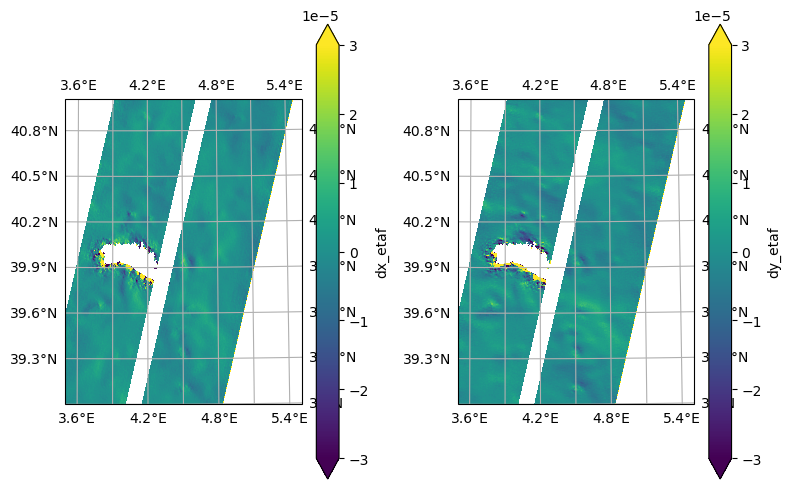

In [34]:
dss0 = xr.open_dataset(f250m[0]).sel(num_lines = slice(1000, 3300))
dss1 = xr.open_dataset(f250m[1]).sel(num_lines = slice(600, 4000))
vmin=-3e-5
vmax= 3e-5


fig = plt.figure(figsize=(8,5))
fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(121, projection=ccrs.Orthographic(4,40))

dss0.dx_etaf.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax)
dss1.dx_etaf.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax, add_colorbar=False)
gl = ax.gridlines(draw_labels=True,)
ax.set_extent(bbox)

fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(122, projection=ccrs.Orthographic(4,40))

dss0.dy_etaf.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax)
dss1.dy_etaf.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax, add_colorbar=False)
gl = ax.gridlines(draw_labels=True,)
ax.set_extent(bbox)
fig.tight_layout()

# Gaussian

In [35]:
f250m = glob(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot250m','*', '*'))
f250m

['/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/gaussian_55000/3_490.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/gaussian_55000/16_552.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/gaussian_55000/3_560.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/gaussian_55000/3_518.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/gaussian_55000/3_504.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/gaussian_55000/3_529.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/gaussian_55000/16_571.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/gaussian_55000/3_489.nc',
 '/home/datawork-lops-oc/aponte/margot

In [36]:
cycle = 500
method = 'gaussian'
cutoff = np.arange(5e3, 60e3, 5e3)
N = len(cutoff)

fig = plt.figure(figsize=(10,5))
for i in range(N):
    dss3 = xr.open_dataset('/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/{method}_{int(cutoff)}/16_484.nc')
    ax = fig.add_subplot(3,4,i, projection=ccrs.Orthographic(4,40))
    


In [6]:
f2km = glob(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot2km','*'))
f2km

['/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot2km/fitting_kernel',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot2km/general',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot2km/gaussian',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot2km/diff_only']

In [37]:
N

11

In [3]:
L4 = glob(os.path.join('/Users/mdemol/DATA_MED_COLOC/before_coloc/L4_sealevel/*'))

In [5]:
fl4 = L4[2]
fl4

'/Users/mdemol/DATA_MED_COLOC/before_coloc/L4_sealevel/L4_with_swot.nc'

In [6]:
dl4 = xr.open_dataset('/Users/mdemol/DATA_MED_COLOC/before_coloc/L4_sealevel/L4_with_swot.nc')

In [7]:
dl4

<xarray.Dataset> Size: 31MB
Dimensions:         (time: 108, latitude: 64, nv: 2, longitude: 56)
Coordinates:
  * time            (time) datetime64[ns] 864B 2023-03-25 ... 2023-07-10
  * latitude        (latitude) float32 256B 36.06 36.19 36.31 ... 43.81 43.94
  * longitude       (longitude) float32 224B 0.0625 0.1875 ... 6.812 6.938
  * nv              (nv) int32 8B 0 1
Data variables: (12/14)
    crs             (time) int32 432B ...
    lat_bnds        (time, latitude, nv) float32 55kB ...
    lon_bnds        (time, longitude, nv) float32 48kB ...
    sla             (time, latitude, longitude) float64 3MB ...
    err_sla         (time, latitude, longitude) float64 3MB ...
    ugosa           (time, latitude, longitude) float64 3MB ...
    ...              ...
    err_vgosa       (time, latitude, longitude) float64 3MB ...
    adt             (time, latitude, longitude) float64 3MB ...
    ugos            (time, latitude, longitude) float64 3MB ...
    vgos            (time, latitude, longitude) float64 3MB ...
    flag_ice        (time, latitude, longitude) float64 3MB ...
    tpa_correction  (time) float64 864B ...
Attributes: (12/42)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    geospatial_vertical_units:       m
    time_coverage_duration:          P1D
    time_coverage_resolution:        P1D
    time_coverage_end:               2023-01-01T12:00:00Z
    time_coverage_start:             2022-12-31T12:00:00Z
    platform:                        Cryosat-2 New Orbit, Sentinel-3B, Altika...

In [25]:
from swot import browse_swot_2km
dfs = browse_swot_2km()

In [14]:
date = pd.to_datetime('2023-05-01')

In [15]:
date

Timestamp('2023-05-01 00:00:00')

In [26]:
date = pd.to_datetime('2023-05-01')


dfs = dfs[(date>dfs.start_time_cut)&(date<dfs.end_time_cut)].reset_index()
ds3 = xr.open_dataset(dfs[dfs.pass_number==3].file.values[0])
ds16 = xr.open_dataset(dfs[dfs.pass_number==16].file.values[0])

ds4 = dl4.interp(time=date)

In [86]:
ds4

<xarray.Dataset> Size: 289kB
Dimensions:         (latitude: 64, nv: 2, longitude: 56)
Coordinates:
  * latitude        (latitude) float32 256B 36.06 36.19 36.31 ... 43.81 43.94
  * longitude       (longitude) float32 224B 0.0625 0.1875 ... 6.812 6.938
  * nv              (nv) int32 8B 0 1
    time            datetime64[ns] 8B 2023-05-01
Data variables: (12/14)
    crs             float64 8B -2.147e+09
    lat_bnds        (latitude, nv) float64 1kB 36.0 36.12 36.12 ... 43.88 44.0
    lon_bnds        (longitude, nv) float64 896B 0.0 0.125 0.125 ... 6.875 7.0
    sla             (latitude, longitude) float64 29kB 0.0916 0.0927 ... nan nan
    err_sla         (latitude, longitude) float64 29kB 0.0184 0.0195 ... nan nan
    ugosa           (latitude, longitude) float64 29kB -0.0625 -0.0978 ... nan
    ...              ...
    err_vgosa       (latitude, longitude) float64 29kB 0.0614 0.0709 ... nan nan
    adt             (latitude, longitude) float64 29kB 0.1417 0.1507 ... nan nan
    ugos            (latitude, longitude) float64 29kB 0.232 0.2375 ... nan nan
    vgos            (latitude, longitude) float64 29kB 0.1733 0.1785 ... nan nan
    flag_ice        (latitude, longitude) float64 29kB 0.0 0.0 nan ... nan nan
    tpa_correction  float64 8B nan
Attributes: (12/42)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    geospatial_vertical_units:       m
    time_coverage_duration:          P1D
    time_coverage_resolution:        P1D
    time_coverage_end:               2023-01-01T12:00:00Z
    time_coverage_start:             2022-12-31T12:00:00Z
    platform:                        Cryosat-2 New Orbit, Sentinel-3B, Altika...

Text(0.5, 1.0, 'SWOT')

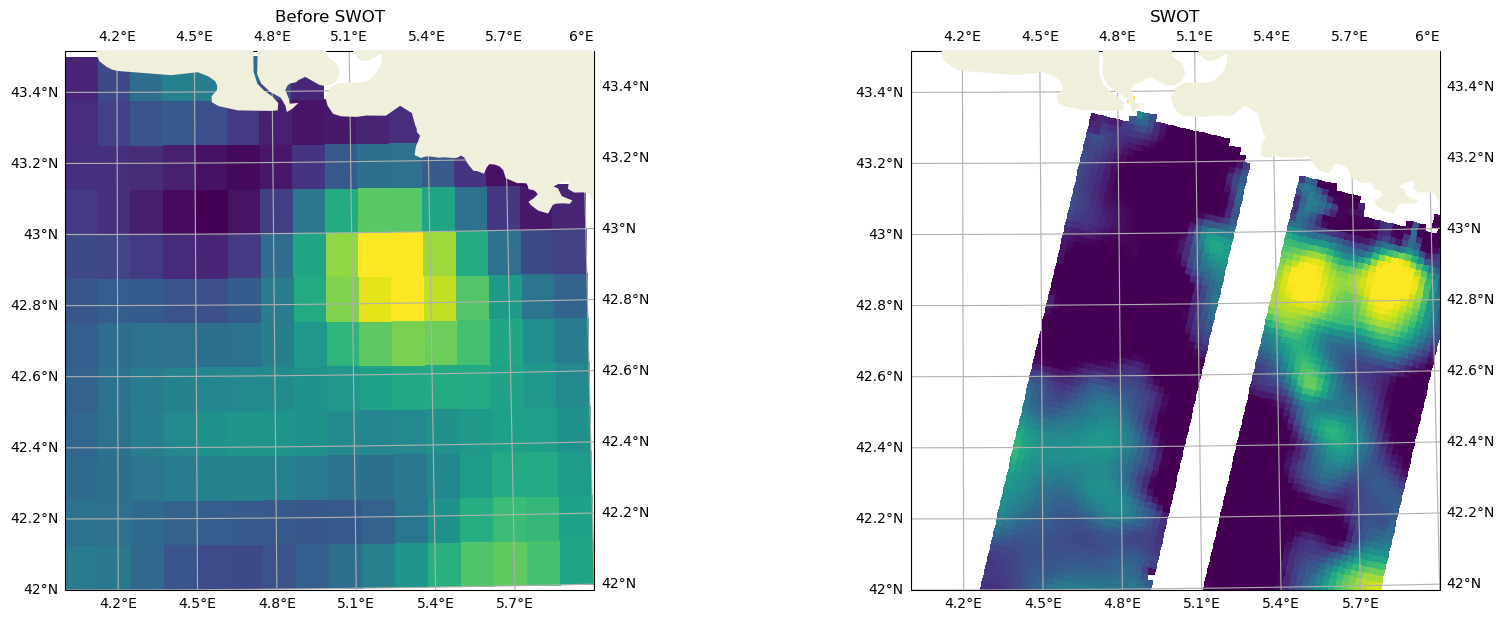

In [76]:
vmin=-0.1
vmax= 0.1

bbox= [4,6, 42, 43.5]

ds4_ = ds4.sel(longitude = slice(bbox[0], bbox[1]),latitude = slice(bbox[2], bbox[3]))

vmin, vmax = ds4_.sla.min(), ds4_.sla.max()

fig = plt.figure(figsize=(20,7))
fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(121, projection=ccrs.Orthographic(4,40))

ds4_.sla.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax, add_colorbar=False,)


ax.set_extent(bbox)
ax.add_feature(cfeature.LAND, zorder=5)
gl = ax.gridlines(draw_labels=True,)
gl.top_xlabels = False
gl.right_ylabels = False
ax.set_title('Before SWOT')

fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(122, projection=ccrs.Orthographic(4,40))

ds3.duacs_ssha_karin_2_filtered.plot(x='longitude', y='latitude',ax=ax, transform=crs , add_colorbar=False, vmin=vmin, vmax=vmax)
ds16.duacs_ssha_karin_2_filtered.plot(x='longitude', y='latitude',ax=ax, transform=crs, add_colorbar=False, vmin=vmin, vmax=vmax)

ax.add_feature(cfeature.LAND, zorder=5)
ax.set_extent(bbox)
gl = ax.gridlines(draw_labels=True,)
gl.top_xlabels = False
gl.right_ylabels = False
ax.set_title('SWOT')


Text(0.5, 1.0, 'SWOT')

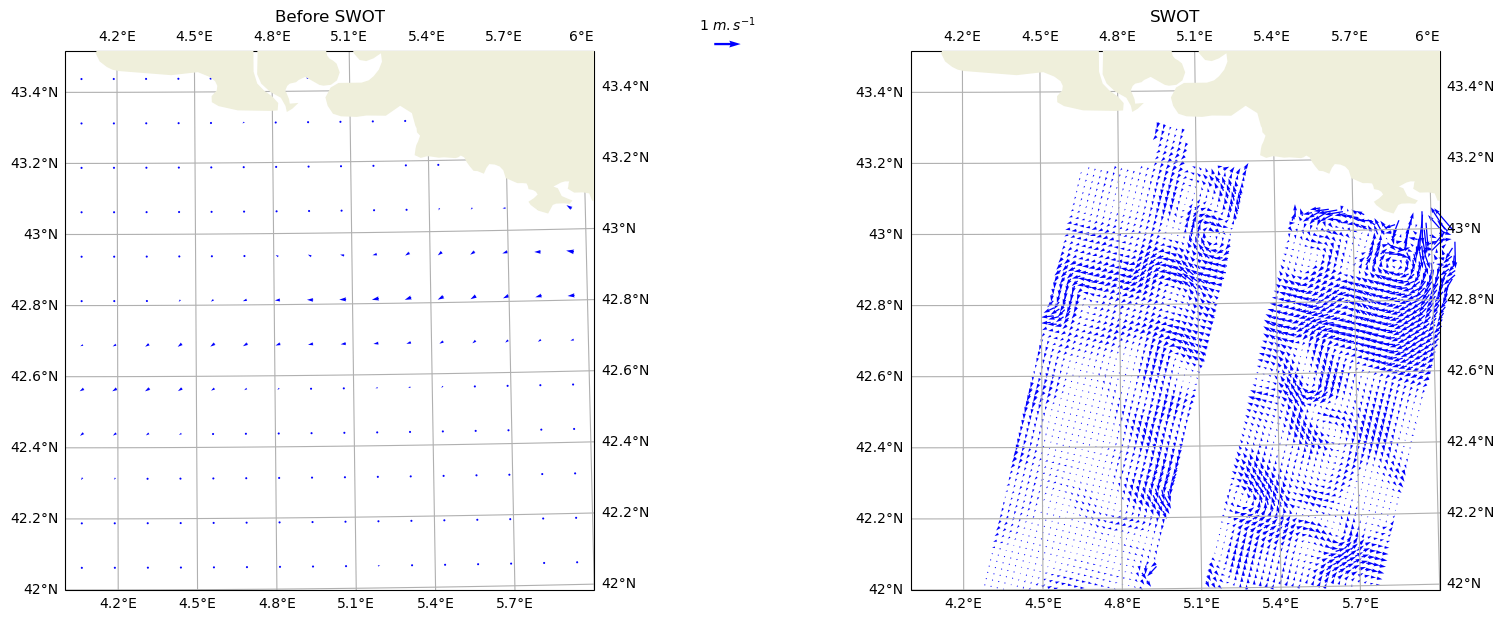

In [98]:
vmin=-0.1
vmax= 0.1

bbox= [4,6, 42, 43.5]

ds4_ = ds4.sel(longitude = slice(bbox[0], bbox[1]),latitude = slice(bbox[2], bbox[3]))

vmin, vmax = ds4_.sla.min(), ds4_.sla.max()

fig = plt.figure(figsize=(20,7))
fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(121, projection=ccrs.Orthographic(4,40))

#ds4_.sla.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax, add_colorbar=False,)

P = ds4_.plot.quiver('longitude', 'latitude','ugos','vgos', color='b', scale = 20, transform=crs, ax=ax, clip_on = False, add_guide = False)
ax.quiverkey(P, 0.5, 0.89, 1, r'1 $m.s^{-1}$', coordinates='figure', labelpos='N')


ax.set_extent(bbox)
ax.add_feature(cfeature.LAND, zorder=5)
gl = ax.gridlines(draw_labels=True,)
gl.top_xlabels = False
gl.right_ylabels = False
ax.set_title('Before SWOT')

fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(122, projection=ccrs.Orthographic(4,40))

#ds3.duacs_ssha_karin_2_filtered.plot(x='longitude', y='latitude',ax=ax, transform=crs , add_colorbar=False, vmin=vmin, vmax=vmax, alpha=0.5)
#ds16.duacs_ssha_karin_2_filtered.plot(x='longitude', y='latitude',ax=ax, transform=crs, add_colorbar=False, vmin=vmin, vmax=vmax)

ds3['ve'] = ds3.duacs_speed_zonal_abs 
ds3['vn'] = ds3.duacs_speed_meridional_abs
dss_c = ds3[['ve', 'vn']].isel(num_lines = slice(0,None,1),num_pixels = slice(0,None,1))
dss_c = dss_c.where(dss_c.latitude>bbox[2]).where(dss_c.latitude<bbox[3])
P = dss_c.plot.quiver('longitude', 'latitude','ve','vn', color='b', scale = 20, transform=crs, ax=ax, clip_on = False, add_guide = False)
#ax.quiverkey(P, 0.8, 0.5, 1, 'SWOT 1/15\n'+r'1 $m.s^{-1}$', coordinates='figure', labelpos='N')

ax.add_feature(cfeature.LAND, zorder=5)
ax.set_extent(bbox)
gl = ax.gridlines(draw_labels=True,)
gl.top_xlabels = False
gl.right_ylabels = False
ax.set_title('SWOT')


Text(0.5, 1.0, 'SWOT')

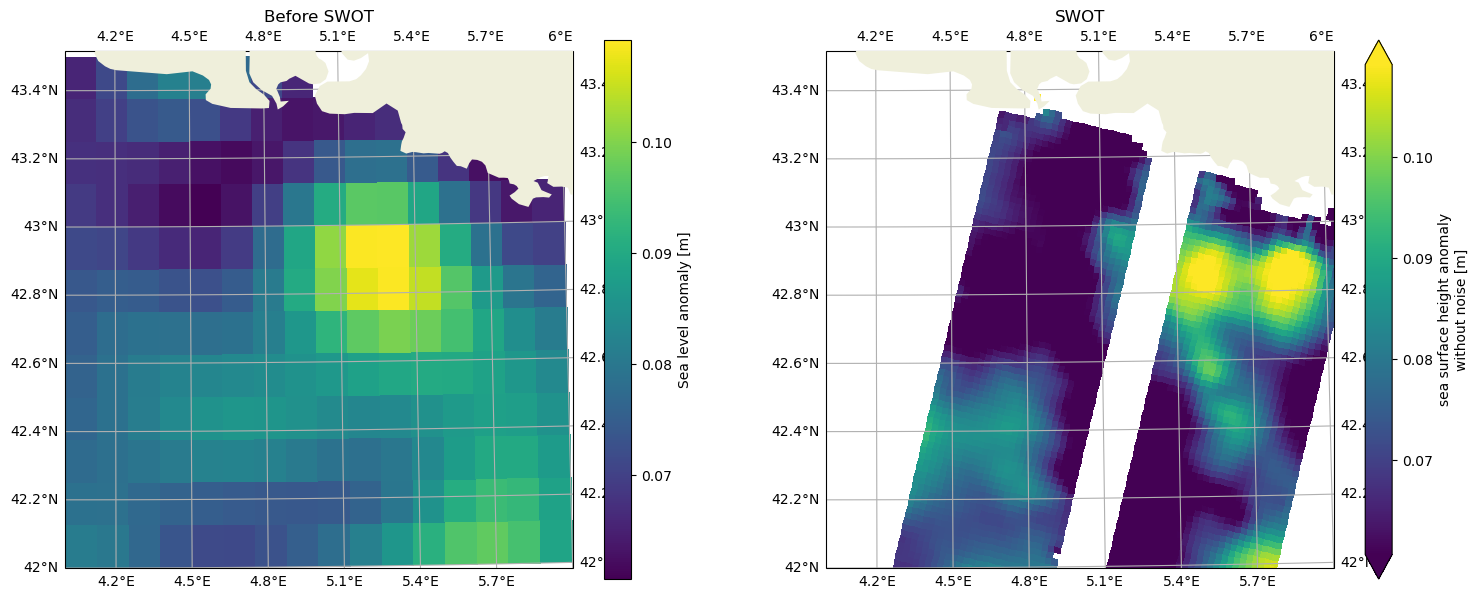

In [77]:
vmin=-0.1
vmax= 0.1

bbox= [4,6, 42, 43.5]

ds4_ = ds4.sel(longitude = slice(bbox[0], bbox[1]),latitude = slice(bbox[2], bbox[3]))

vmin, vmax = ds4_.sla.min(), ds4_.sla.max()

fig = plt.figure(figsize=(18,7))
fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(121, projection=ccrs.Orthographic(4,40))

ds4_.sla.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax, )


ax.set_extent(bbox)
ax.add_feature(cfeature.LAND, zorder=5)
gl = ax.gridlines(draw_labels=True,)
gl.top_xlabels = False
gl.right_ylabels = False
ax.set_title('Before SWOT')

fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(122, projection=ccrs.Orthographic(4,40))

ds3.duacs_ssha_karin_2_filtered.plot(x='longitude', y='latitude',ax=ax, transform=crs , add_colorbar=False, vmin=vmin, vmax=vmax)
ds16.duacs_ssha_karin_2_filtered.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax)

ax.add_feature(cfeature.LAND, zorder=5)
ax.set_extent(bbox)
gl = ax.gridlines(draw_labels=True,)
gl.top_xlabels = False
gl.right_ylabels = False
ax.set_title('SWOT')
